## 🌊 IEA Wind Task 55

**Concepts:** [Warm-starting](../routers.md#warm-starting) **Reference:** [Input Formats](../reference/input_formats.md) **Advanced API:** [🌊 IEA Wind Task 55](lo41_example_iea_wind_task_55.ipynb)

This notebook applies _OptiWindNet_ to design collection system networks for the two offshore wind plants described in the _IEA Wind TCP Task 55_ report (740 MW, 10 MW turbines). Using regular and irregular turbine layouts in windIO format, it uses [HGSRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter) to build a warm start and [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) with the OR-Tools solver for final optimization.

For more information, see _IEA Wind TCP Task 55: The IEA Wind 740-10-MW Reference Offshore Wind Plants_: <https://www.osti.gov/biblio/2333634/>.

### Load required data

#### Import required modules

In [1]:
from prettyTables import Table

from optiwindnet.api import HGSRouter, MILPRouter, ModelOptions, WindFarmNetwork

In [2]:
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

#### Cable data

In [3]:
cables = [(2, 1500.0), (5, 1800.0), (7, 2000.0)]

#### Load turbine layouts

Load the regular and irregular turbine layouts from windIO YAML files.

In [4]:
wfn_reg = WindFarmNetwork.from_windIO(
    filepath='data/IEA37_Borssele_Regular_System.yaml', cables=cables
)

In [5]:
wfn_irr = WindFarmNetwork.from_windIO(
    filepath='data/IEA37_Borssele_Irregular_System.yaml', cables=cables
)

#### Plot locations' geometry.

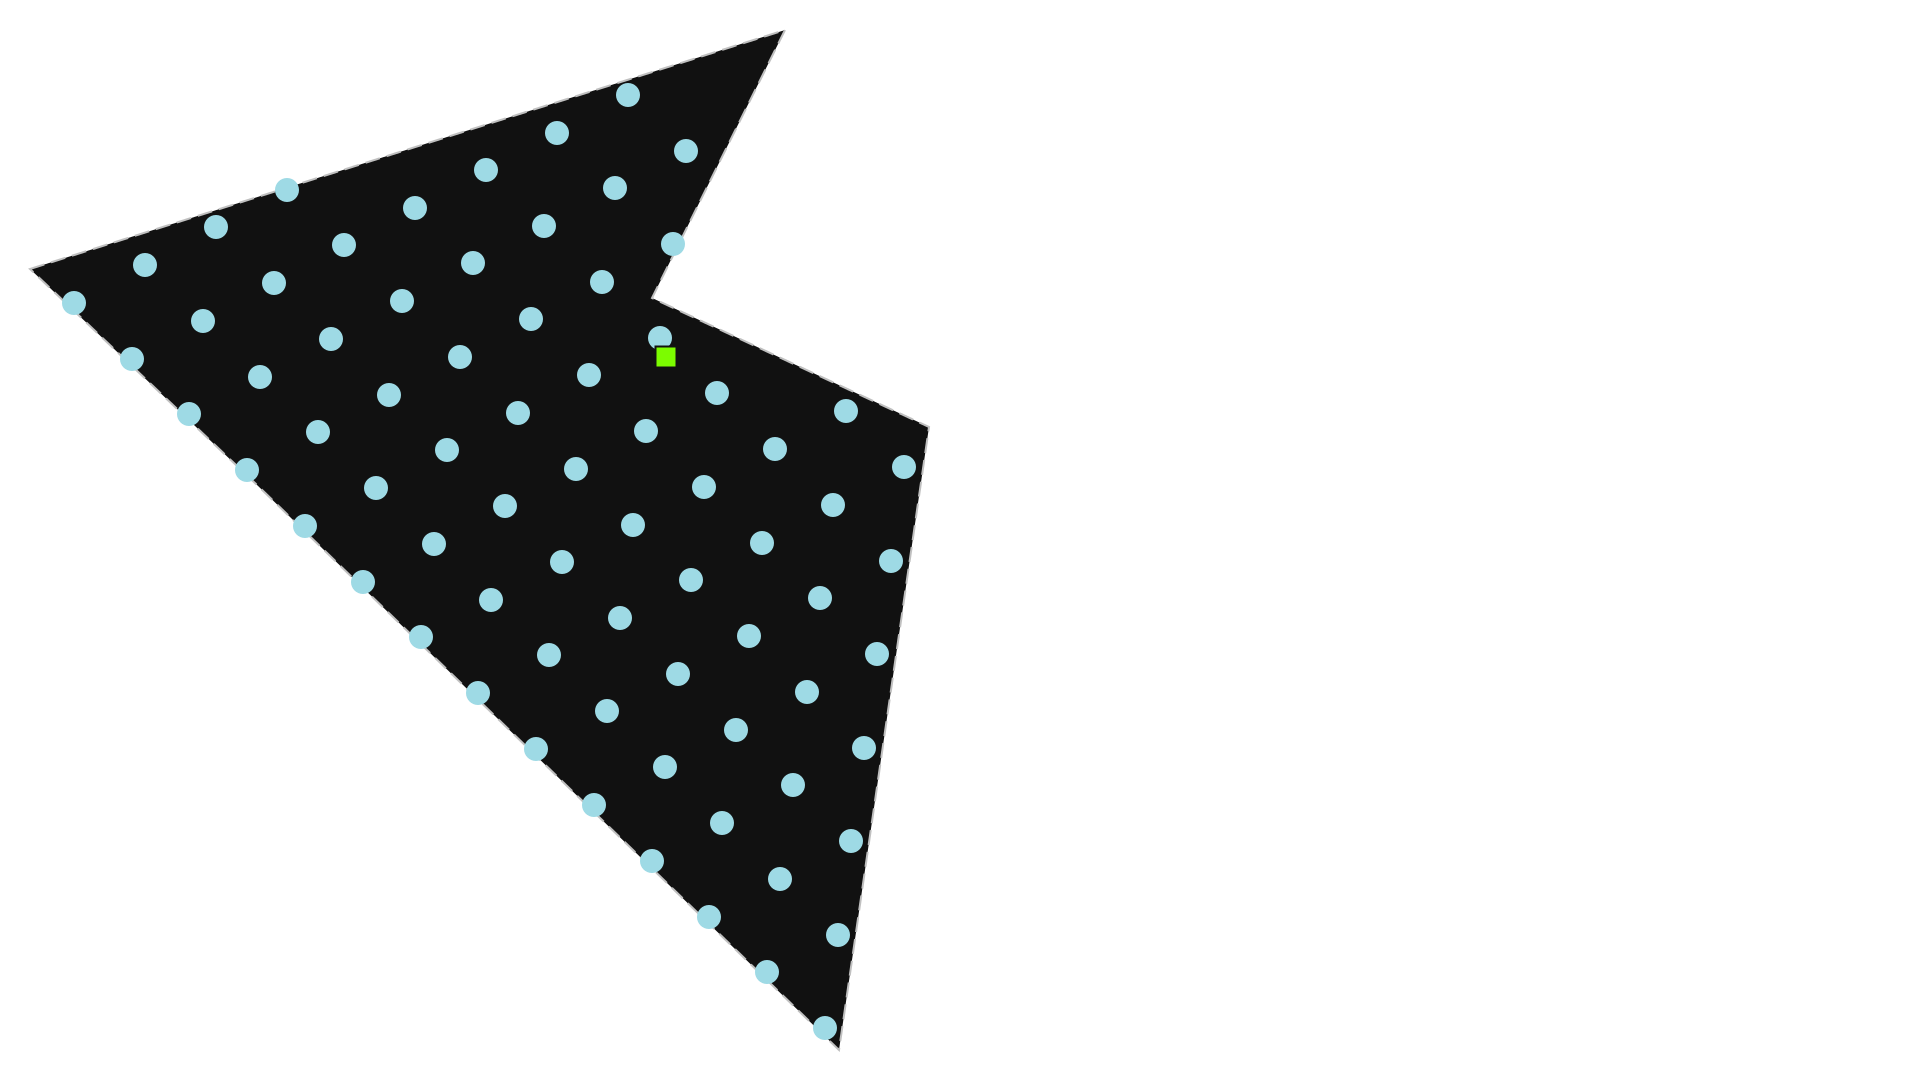

In [6]:
wfn_reg

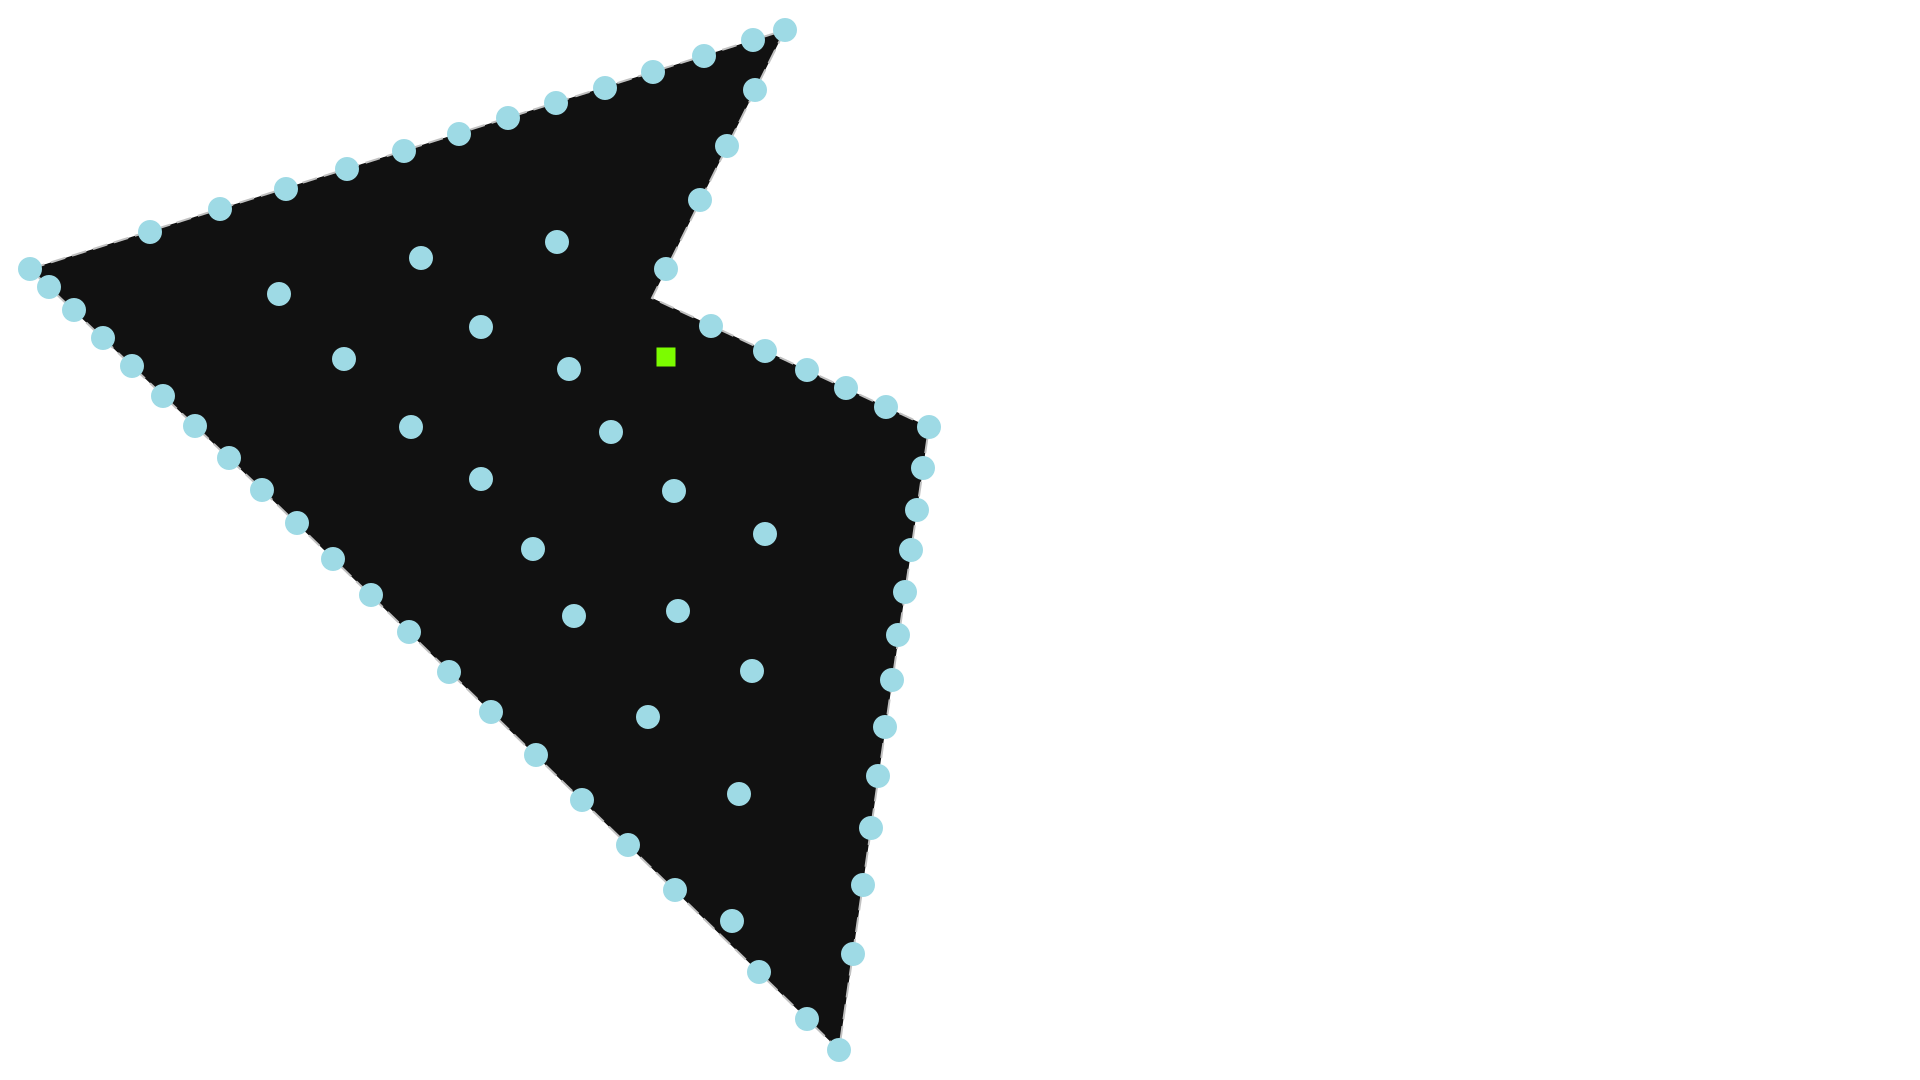

In [7]:
wfn_irr

### Choose the warm-start and main routers

In [8]:
warmstart_router = HGSRouter(time_limit=1, seed=1234567)

solver_options = {
    'num_workers': 8,
    'random_seed': 1234567,
}

model_options = ModelOptions(
    topology='branched',
    feeder_limit='unlimited',
    feeder_route='segmented',
)
milp_router = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=5,
    mip_gap=0.005,
    solver_options=solver_options,
    model_options=model_options,
)

> For details about the `model_options` and `solver_options` of MILP routers, see [🔧 Options](hi31_options.ipynb) and [🎯 MILPRouter](hi23_milp.ipynb).

### Regular turbine layout

#### Warm start

In [9]:
res_reg_warm = wfn_reg.optimize(router=warmstart_router)

In [10]:
wfn_reg.solution_info()

{'router': 'HGSRouter',
 'capacity': 7,
 'solver_name': 'HGS-CVRP',
 'complete': False,
 'feeders_above_min': None,
 'feeders_exact': False,
 'balanced': False,
 'ringed': False,
 'repair': True,
 'max_retries': 10,
 'nbGranular': 20,
 'mu': 25,
 'lambda_': 40,
 'nbElite': 4,
 'nbClose': 5,
 'nbIterPenaltyManagement': 100,
 'targetFeasible': 0.2,
 'penaltyDecrease': 0.85,
 'penaltyIncrease': 1.2,
 'seed': 1234567,
 'nbIter': 20000,
 'nbIterTraces': 500,
 'timeLimit': 1,
 'useSwapStar': True,
 'runtime': 1.000120329}

Check the total length of the warm-start solution:

In [11]:
wfn_reg.length()

139656.4789599965

#### Optimize with MILP router

In [12]:
res_reg = wfn_reg.optimize(router=milp_router)

In [13]:
wfn_reg.solution_info()

{'router': 'MILPRouter',
 'capacity': 7,
 'solver_name': 'ortools.cp_sat',
 'mip_gap': 0.005,
 'time_limit': 5,
 'topology': <Topology.BRANCHED: 'branched'>,
 'feeder_route': <FeederRoute.SEGMENTED: 'segmented'>,
 'feeder_limit': <FeederLimit.UNLIMITED: 'unlimited'>,
 'balanced': False,
 'runtime': 5.027718,
 'bound': 136520.6996290641,
 'objective': 139645.18265363993,
 'relgap': 0.02237444189052662,
 'termination': 'FEASIBLE'}

In [14]:
wfn_reg.length()

139645.18265364

In [15]:
wfn_reg.cost()

248112330.12342116

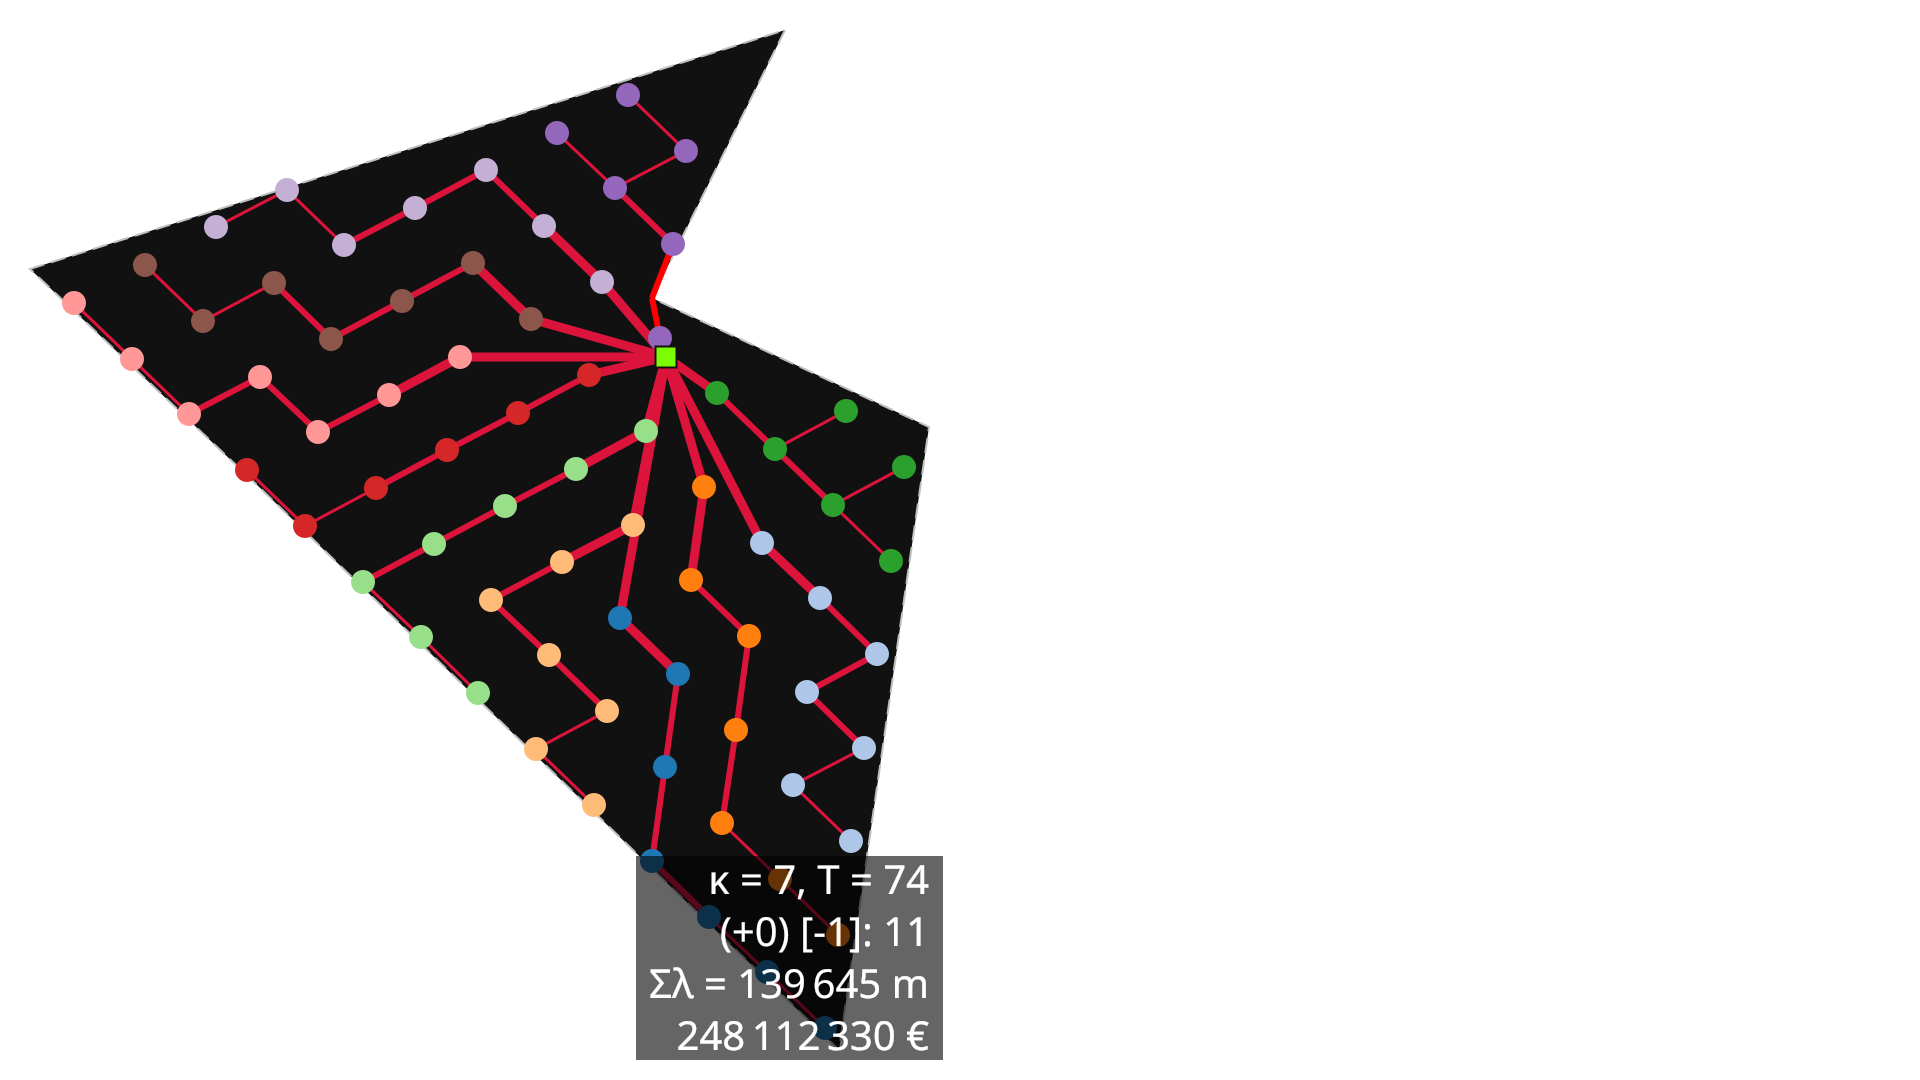

In [16]:
wfn_reg

### Irregular turbine layout

In [17]:
res_irr_warmup = wfn_irr.optimize(router=warmstart_router)

In [18]:
wfn_irr.solution_info()

{'router': 'HGSRouter',
 'capacity': 7,
 'solver_name': 'HGS-CVRP',
 'complete': False,
 'feeders_above_min': None,
 'feeders_exact': False,
 'balanced': False,
 'ringed': False,
 'repair': True,
 'max_retries': 10,
 'nbGranular': 20,
 'mu': 25,
 'lambda_': 40,
 'nbElite': 4,
 'nbClose': 5,
 'nbIterPenaltyManagement': 100,
 'targetFeasible': 0.2,
 'penaltyDecrease': 0.85,
 'penaltyIncrease': 1.2,
 'seed': 1234567,
 'nbIter': 20000,
 'nbIterTraces': 500,
 'timeLimit': 1,
 'useSwapStar': True,
 'runtime': 1.000287001}

Check the total length of the warm-start solution:

In [19]:
wfn_irr.length()

136472.24805009153

#### Optimize with MILP router

In [20]:
res_irr = wfn_irr.optimize(router=milp_router)

In [21]:
wfn_irr.solution_info()

{'router': 'MILPRouter',
 'capacity': 7,
 'solver_name': 'ortools.cp_sat',
 'mip_gap': 0.005,
 'time_limit': 5,
 'topology': <Topology.BRANCHED: 'branched'>,
 'feeder_route': <FeederRoute.SEGMENTED: 'segmented'>,
 'feeder_limit': <FeederLimit.UNLIMITED: 'unlimited'>,
 'balanced': False,
 'runtime': 5.01778,
 'bound': 130402.96678355354,
 'objective': 134786.7922581253,
 'relgap': 0.03252414721893859,
 'termination': 'FEASIBLE'}

In [22]:
wfn_irr.length()

134807.7634895362

In [23]:
wfn_irr.cost()

247033944.13135293

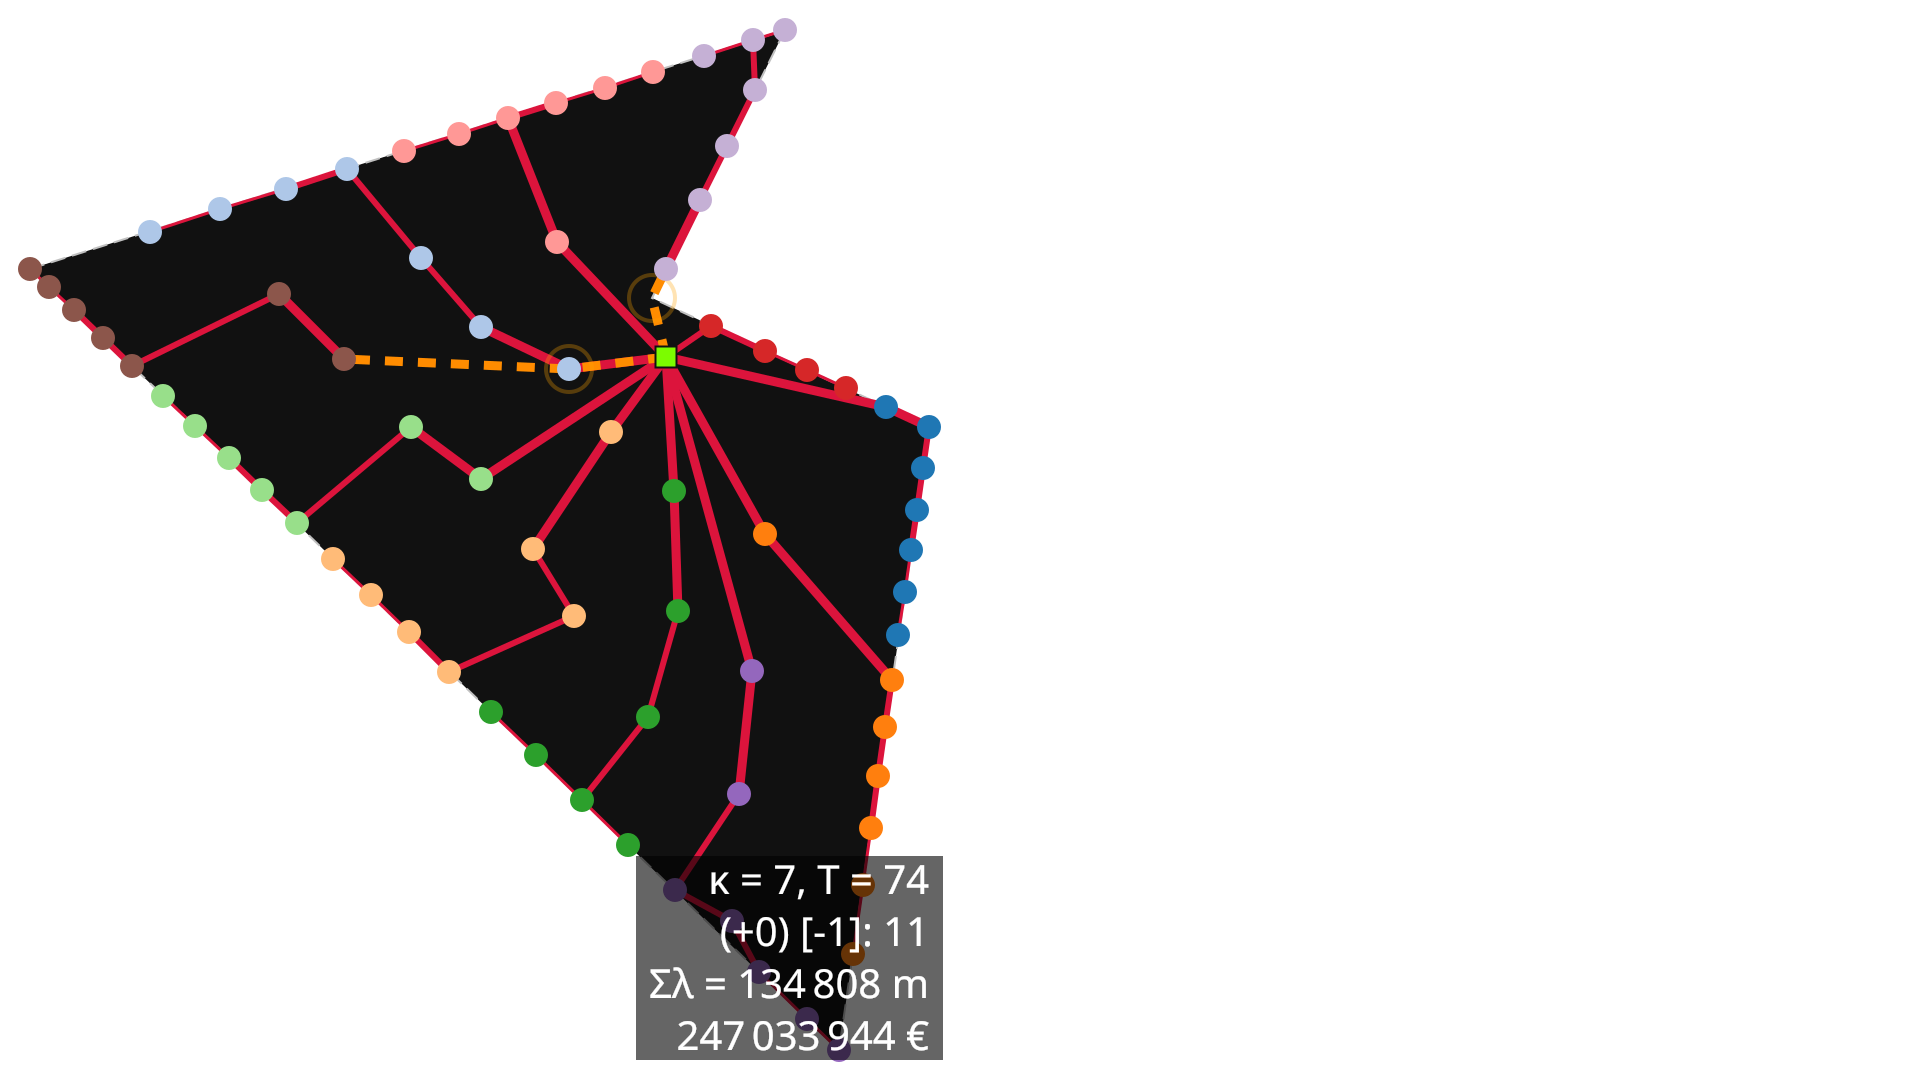

In [24]:
wfn_irr

### Layouts' edge list

These lists of 3-tuples contain all edges and their cable types (as indices into the `turbines_per_cable` list), that is, `(coordinate_A, coordinate_B, cable_type)`.

Negative node indices represent substations. Node indices from 0 to 73 represent the turbines in input order.

If the network has contours or detours, node indices may exceed the number of coordinates in the routed graph's `VertexC` array. The mapping from each additional node index to its coordinate index in `VertexC` is shown below. `VertexC` includes the input coordinates and may also include vertices generated while building the navigation mesh.

In [25]:
wfn_reg.G.edges(data='cable')

EdgeDataView([(-1, 47, 2), (-1, 56, 2), (-1, 46, 2), (-1, 33, 2), (-1, 45, 2), (-1, 57, 2), (-1, 34, 2), (-1, 24, 2), (-1, 49, 2), (-1, 58, 2), (-1, 32, 2), (0, 1, 0), (1, 4, 0), (2, 3, 0), (3, 8, 0), (4, 5, 1), (5, 9, 1), (6, 7, 0), (7, 12, 0), (8, 14, 1), (9, 15, 1), (10, 11, 0), (11, 16, 0), (12, 13, 1), (13, 20, 1), (14, 22, 1), (15, 24, 2), (16, 17, 1), (17, 26, 1), (18, 19, 0), (19, 28, 0), (20, 21, 1), (21, 32, 2), (22, 23, 1), (23, 33, 2), (25, 26, 1), (25, 34, 2), (27, 28, 1), (27, 36, 1), (29, 38, 0), (29, 40, 0), (30, 31, 0), (31, 44, 1), (31, 42, 0), (35, 36, 1), (35, 46, 2), (37, 48, 1), (37, 38, 1), (39, 50, 1), (39, 52, 1), (41, 52, 1), (41, 54, 0), (43, 44, 0), (44, 45, 1), (47, 48, 1), (49, 50, 2), (51, 62, 1), (51, 60, 1), (53, 62, 0), (53, 64, 0), (54, 55, 0), (56, 80, 1), (57, 67, 2), (58, 59, 2), (59, 60, 1), (61, 70, 0), (61, 69, 1), (63, 70, 0), (65, 80, 1), (65, 66, 1), (66, 71, 0), (66, 73, 0), (67, 68, 1), (68, 69, 1), (71, 72, 0)])

Alternatively, [get_network()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.get_network) returns the final cabling network as a structured array from which individual edge fields can be extracted. The tables below show the first rows.

#### Regular turbine layout

In [26]:
network_reg = wfn_reg.get_network()
print(network_reg.dtype.names)

('src', 'tgt', 'length', 'load', 'cable')


In [27]:
Table(columns={k: network_reg[k][:8] for k in ('src', 'tgt', 'cable')})

src,tgt,cable
47,-1,2
56,-1,2
46,-1,2
33,-1,2
45,-1,2
57,-1,2
34,-1,2
24,-1,2


#### Irregular turbine layout

In [28]:
network_irr = wfn_irr.get_network()
Table(columns={k: network_irr[k][:8] for k in ('src', 'tgt', 'cable')})

src,tgt,cable
41,-1,2
28,-1,2
49,-1,2
55,-1,1
39,-1,2
60,-1,2
70,-1,2
25,-1,2


### Mapping of contour/detour

Map each contour or detour node to the index of its `VertexC` coordinate:

In [29]:
wfn_reg.map_detour_vertex()

{80: 76}

In [30]:
wfn_irr.map_detour_vertex()

{80: 28, 81: 76}